In [ ]:
"""
=============================================================
  Netflix Content Analysis 
  Author : Purvi Vaja
  Dataset: netflix_titles.csv  
  Tools  : pandas · numpy · matplotlib · seaborn · plotly
=============================================================
"""

In [1]:
# Import library

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import seaborn as sns
from collections import Counter
import re, os

In [2]:
print("\n" + "="*50)
print("  NETFLIX CONTENT ANALYSIS")
print("="*50)

df = pd.read_csv("netflix_titles.csv")
print(f"\nLoaded {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n── Column types ──")
print(df.dtypes)


  NETFLIX CONTENT ANALYSIS

Loaded 8,807 rows × 12 columns

── Column types ──
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [3]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Missing Values
print("\n── Missing values ──")
missing = df.isnull().sum()
print(missing[missing > 0])


── Missing values ──
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [5]:
# Data Cleaning 
# Convert date column into datetime format
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    errors="coerce"
)

# Extract year and month
df["year_added"] = df["date_added"].dt.year.astype("Int64")
df["month_added"] = df["date_added"].dt.month.astype("Int64")

# Extract month short name
df["month_name"] = df["date_added"].dt.strftime("%b")

# Extract numeric duration
df["duration_int"] = (
    df["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

# Extract first genre
df["main_genre"] = (
    df["listed_in"]
    .str.split(",")
    .str[0]
    .str.strip()
)

# Extract first country
df["main_country"] = (
    df["country"]
    .str.split(",")
    .str[0]
    .str.strip()
)

# Years taken to appear on Netflix
df["years_to_add"] = (
    df["year_added"] - df["release_year"]
)

# Fill missing ratings
df["rating"].fillna("Not Rated", inplace=True)

In [6]:
# ──  Summary Statistics ────────────────────────────────────
print("\n── Dataset Summary ──")
movies = df[df["type"] == "Movie"]
shows  = df[df["type"] == "TV Show"]
print(f"  Movies  : {len(movies):,}  ({len(movies)/len(df)*100:.1f}%)")
print(f"  TV Shows: {len(shows):,}  ({len(shows)/len(df)*100:.1f}%)")
print(f"\n  Avg movie runtime : {movies['duration_int'].mean():.1f} min")
print(f"  Avg TV show seasons: {shows['duration_int'].mean():.1f}")
print(f"\n  Year range: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"  Countries: {df['main_country'].nunique()}")
print(f"  Unique genres: {df['main_genre'].nunique()}")


── Dataset Summary ──
  Movies  : 6,131  (69.6%)
  TV Shows: 2,676  (30.4%)

  Avg movie runtime : 99.6 min
  Avg TV show seasons: 1.8

  Year range: 1925 – 2021
  Countries: 86
  Unique genres: 36


In [7]:
# ─ Matplotlib Charts
PALETTE = ["#E50914","#B81D24","#F5F5F1","#564D4D","#221F1F"]
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams.update({"figure.facecolor":"#221F1F","axes.facecolor":"#2b2b2b",
                     "axes.labelcolor":"#F5F5F1","xtick.color":"#F5F5F1",
                     "ytick.color":"#F5F5F1","text.color":"#F5F5F1",
                     "grid.color":"#3a3a3a","font.family":"DejaVu Sans"})
 

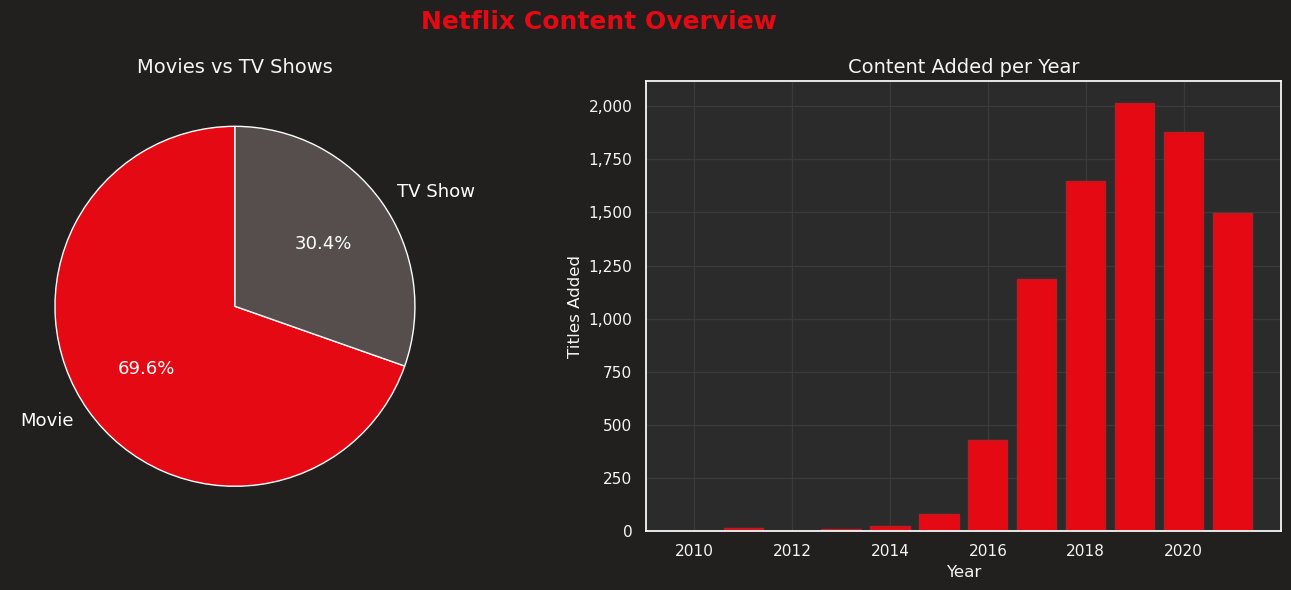

In [8]:
# Content Type Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Netflix Content Overview", fontsize=18, fontweight="bold", color="#E50914")
 
type_counts = df["type"].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
            colors=["#E50914","#564D4D"], startangle=90,
            textprops={"color":"white","fontsize":13})
axes[0].set_title("Movies vs TV Shows", fontsize=14)

# Yearly additions bar
yearly = df.groupby("year_added")["show_id"].count().dropna()
yearly = yearly[yearly.index >= 2010]
axes[1].bar(yearly.index.astype(int), yearly.values, color="#E50914", edgecolor="#b81d24")
axes[1].set_title("Content Added per Year", fontsize=14)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Titles Added")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
 
plt.tight_layout()


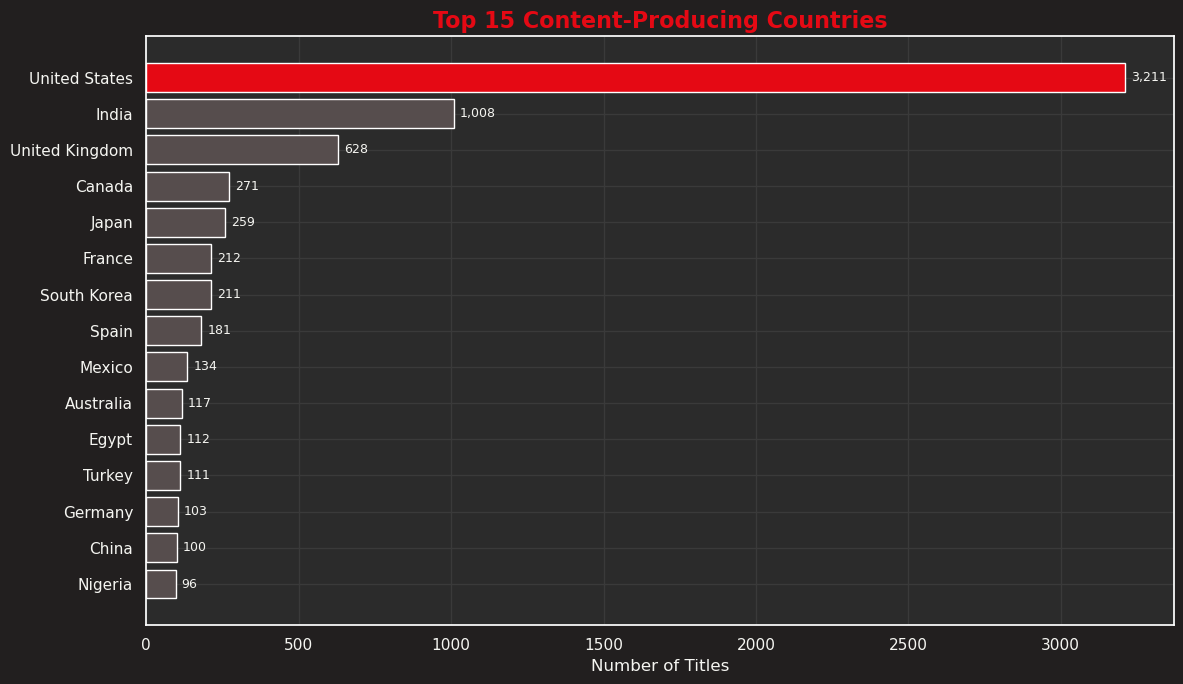

In [9]:
# Top Countries 
top_countries = (df["main_country"].value_counts()
                   .dropna().head(15))
 
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#E50914" if i == 0 else "#564D4D" for i in range(len(top_countries))]
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=colors[::-1])
ax.set_title("Top 15 Content-Producing Countries", fontsize=16, fontweight="bold", color="#E50914")
ax.set_xlabel("Number of Titles")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 20, bar.get_y() + bar.get_height()/2,
            f"{int(w):,}", va="center", fontsize=9, color="#F5F5F1")
plt.tight_layout()


<function matplotlib.pyplot.show(close=None, block=None)>

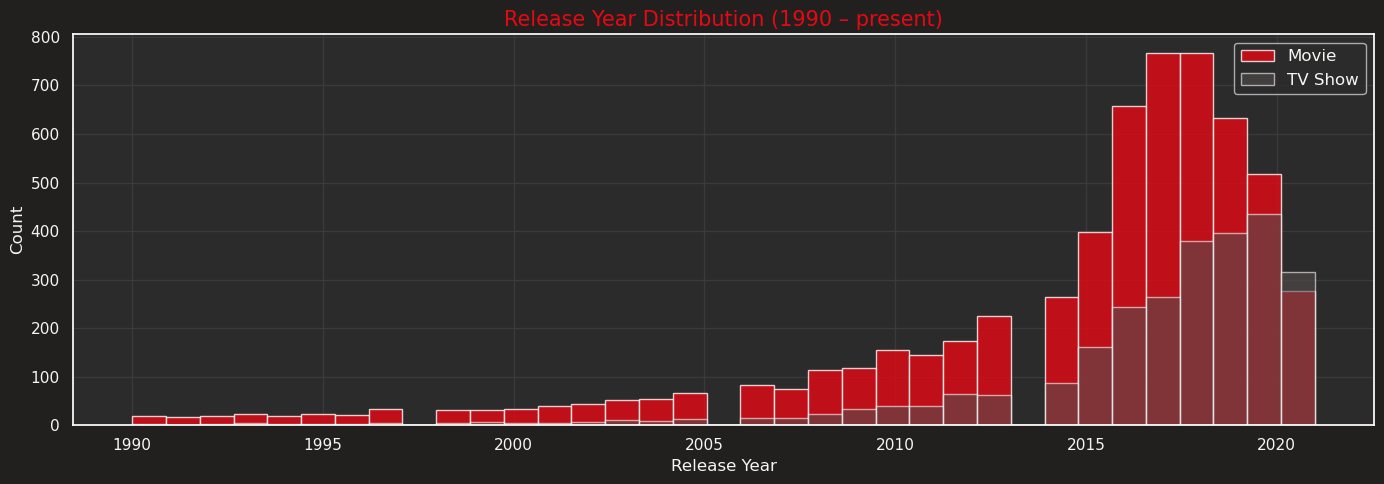

In [10]:
# Release Year Distribution 
fig, ax = plt.subplots(figsize=(14, 5))
recent = df[df["release_year"] >= 1990]
ax.hist(recent[recent["type"]=="Movie"]["release_year"],  bins=35,
        alpha=0.8, label="Movie",   color="#E50914")
ax.hist(recent[recent["type"]=="TV Show"]["release_year"], bins=35,
        alpha=0.6, label="TV Show", color="#564D4D")
ax.set_title("Release Year Distribution (1990 – present)", fontsize=15, color="#E50914")
ax.set_xlabel("Release Year")
ax.set_ylabel("Count")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

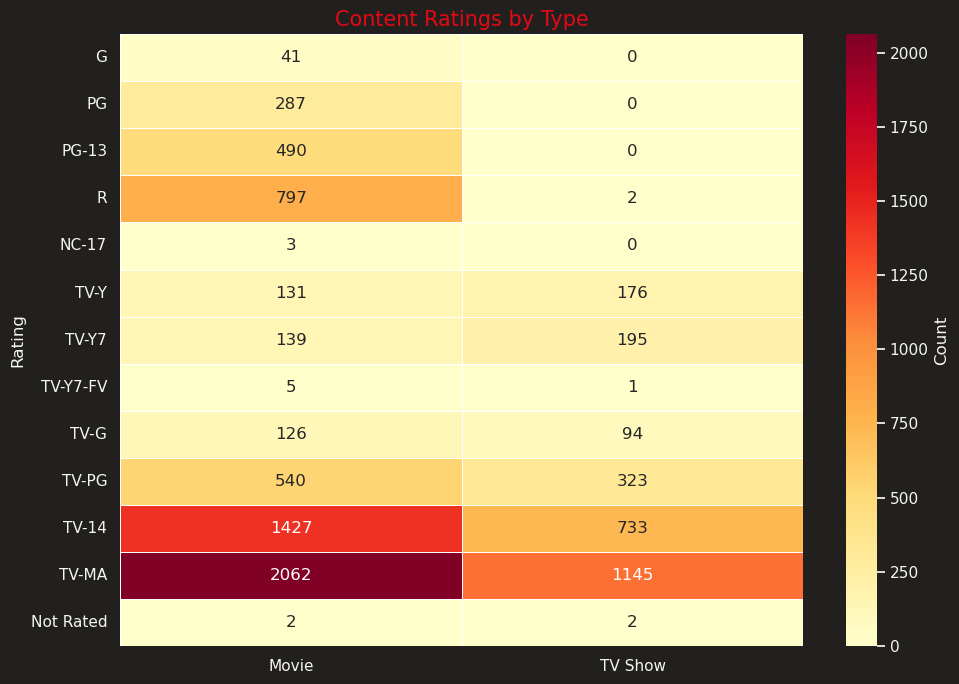

In [11]:
# Rating heatmap by type 
rating_order = ["G","PG","PG-13","R","NC-17","TV-Y","TV-Y7",
                "TV-Y7-FV","TV-G","TV-PG","TV-14","TV-MA","Not Rated"]
rating_counts = (df.groupby(["rating","type"])["show_id"]
                   .count().unstack(fill_value=0))
present = [r for r in rating_order if r in rating_counts.index]
rating_counts = rating_counts.loc[present]
 
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(rating_counts, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label":"Count"})
ax.set_title("Content Ratings by Type", fontsize=15, color="#E50914")
ax.set_xlabel("")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

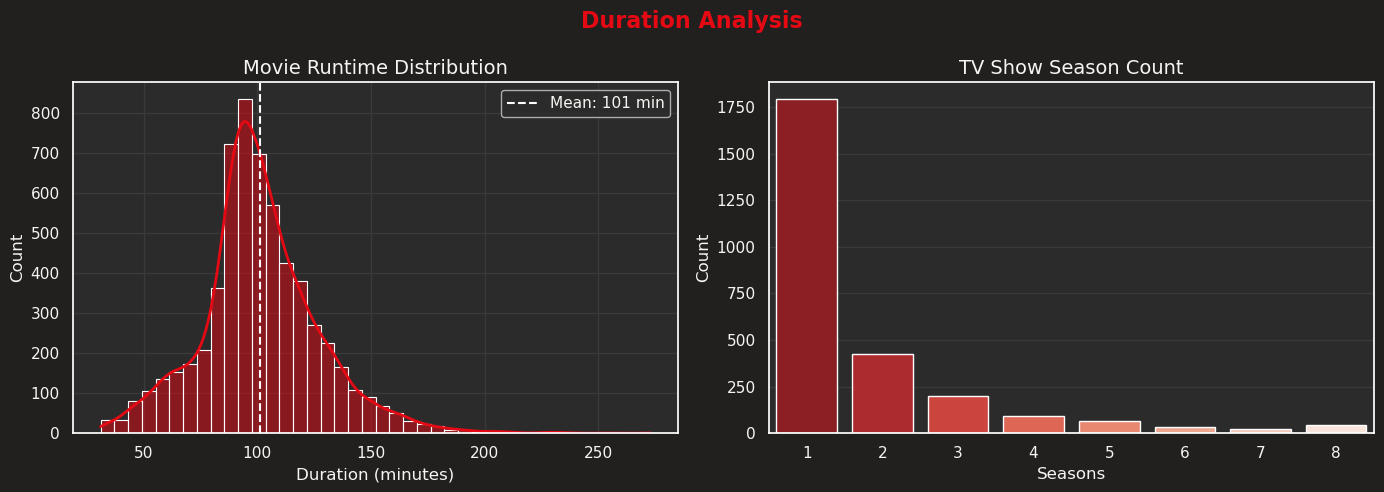

In [12]:
# Movie Duration Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
movie_dur = movies["duration_int"].dropna()
movie_dur = movie_dur[(movie_dur > 30) & (movie_dur < 300)]
 
sns.histplot(movie_dur, bins=40, kde=True, ax=axes[0],
             color="#E50914", line_kws={"color":"white","lw":2})
axes[0].set_title("Movie Runtime Distribution", fontsize=14)
axes[0].set_xlabel("Duration (minutes)")
axes[0].axvline(movie_dur.mean(), color="white", linestyle="--",
                label=f"Mean: {movie_dur.mean():.0f} min")
axes[0].legend()

# TV show seasons
show_dur = shows["duration_int"].dropna()
sns.countplot(x=show_dur.clip(upper=8).astype(int), ax=axes[1],
              palette="Reds_r")
axes[1].set_title("TV Show Season Count", fontsize=14)
axes[1].set_xlabel("Seasons")
axes[1].set_ylabel("Count")
 
plt.suptitle("Duration Analysis", fontsize=16, fontweight="bold", color="#E50914")
plt.tight_layout()
plt.show

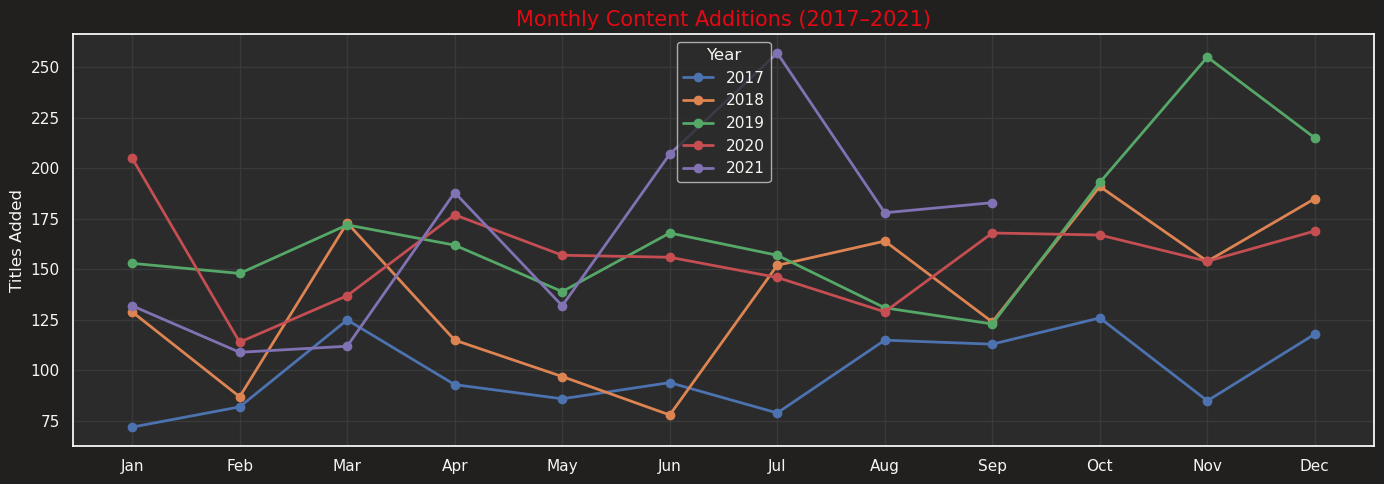

In [13]:
# Monthly additions (line) 
monthly = (df.groupby(["year_added","month_added"])["show_id"]
             .count().reset_index())
monthly = monthly[monthly["year_added"].between(2017, 2021)]
 
fig, ax = plt.subplots(figsize=(14, 5))
for year, grp in monthly.groupby("year_added"):
    ax.plot(grp["month_added"], grp["show_id"], marker="o",
            label=str(int(year)), linewidth=2)
ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Monthly Content Additions (2017–2021)", fontsize=15, color="#E50914")
ax.set_ylabel("Titles Added")
ax.legend(title="Year")
plt.tight_layout()

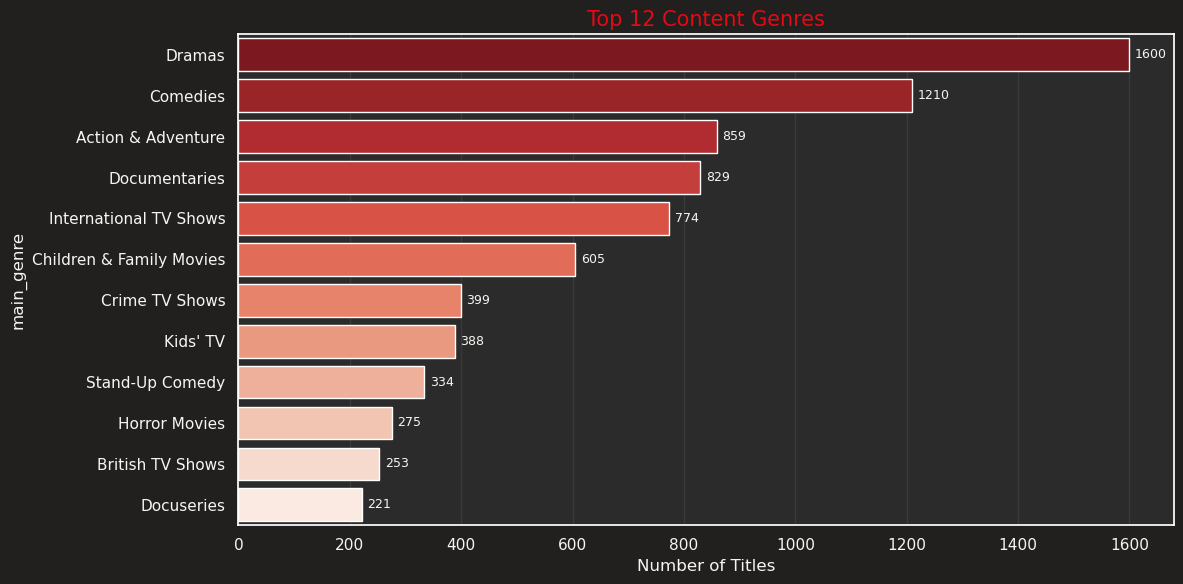

In [14]:
# Top 12 genres 
top_genres = df["main_genre"].value_counts().head(12)
 
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="Reds_r", ax=ax)
ax.set_title("Top 12 Content Genres", fontsize=15, color="#E50914")
ax.set_xlabel("Number of Titles")
for i, v in enumerate(top_genres.values):
    ax.text(v + 10, i, str(v), va="center", fontsize=9)
plt.tight_layout()

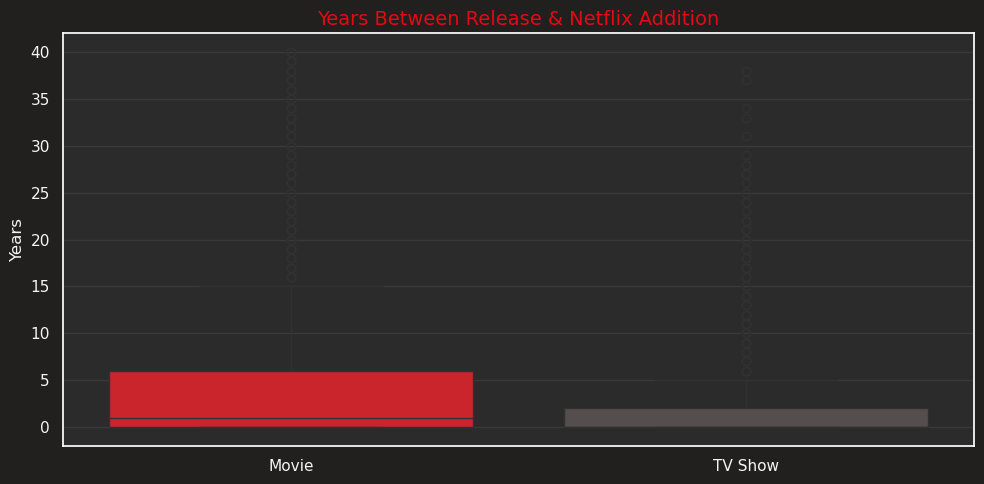

In [15]:
#  Years-to-add box plot
df_yta = df[df["years_to_add"].between(0, 40)].copy()
 
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_yta, x="type", y="years_to_add",
            palette={"Movie":"#E50914","TV Show":"#564D4D"}, ax=ax)
ax.set_title("Years Between Release & Netflix Addition", fontsize=14, color="#E50914")
ax.set_xlabel("")
ax.set_ylabel("Years")
plt.tight_layout()

In [16]:
# Choropleth Map
country_counts = df["main_country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]

fig_map = px.choropleth(
    country_counts,
    locations="country",
    locationmode="country names",
    color="count",
    color_continuous_scale="Reds",
    title="Netflix Content by Country",
    template="plotly_dark"
)

fig_map.show()


# Sunburst Chart
top_genres = df["main_genre"].value_counts()

sun_df = df[
    df["main_genre"].isin(top_genres.index[:8])
].copy()

fig_sun = px.sunburst(
    sun_df,
    path=["type", "rating", "main_genre"],
    title="Content Hierarchy",
    template="plotly_dark"
)

fig_sun.show()


# Treemap
genre_df = df["main_genre"].value_counts().reset_index()
genre_df.columns = ["genre", "count"]

fig_tree = px.treemap(
    genre_df.head(20),
    path=["genre"],
    values="count",
    title="Top 20 Genres",
    template="plotly_dark"
)

fig_tree.show()

In [17]:
# NumPy Analysis

print("\n── NumPy Insights ──")

# Movie durations
durations = movies["duration_int"].dropna().values

mean_duration = np.mean(durations)
median_duration = np.median(durations)
std_duration = np.std(durations)

p25 = np.percentile(durations, 25)
p75 = np.percentile(durations, 75)

print(f"Movie Duration Mean    : {mean_duration:.1f} min")
print(f"Movie Duration Median  : {median_duration:.1f} min")
print(f"Movie Duration Std Dev : {std_duration:.1f} min")
print(f"25th / 75th Percentile : {p25:.0f} / {p75:.0f} min")


# Correlation between release year and duration
corr_data = df[["release_year", "duration_int"]].dropna()

correlation = np.corrcoef(
    corr_data["release_year"],
    corr_data["duration_int"]
)[0,1]

print(
    f"\nCorrelation "
    f"(Release Year vs Duration): "
    f"{correlation:.4f}"
)


# Yearly growth analysis
yearly_titles = (
    df.groupby("year_added")["show_id"]
    .count()
)

yearly_titles = yearly_titles[
    (yearly_titles.index >= 2017)
    & (yearly_titles.index <= 2021)
]

growth_rate = (
    np.diff(yearly_titles.values)
    / yearly_titles.values[:-1]
    * 100
)

growth_text = " → ".join(
    [f"{g:.1f}%" for g in growth_rate]
)

print(
    f"\nYoY Content Growth "
    f"(2017→2021): {growth_text}"
)


── NumPy Insights ──
Movie Duration Mean    : 99.6 min
Movie Duration Median  : 98.0 min
Movie Duration Std Dev : 28.3 min
25th / 75th Percentile : 87 / 114 min

Correlation (Release Year vs Duration): -0.2492

YoY Content Growth (2017→2021): 38.8% → 22.3% → -6.8% → -20.3%
